# Задание Ultra Pro

Используя базу данных автомобилей, создайте сеть с точностью распознавания не ниже 93% на проверочной выборке.

Для решения задачи вы можете использовать любой подход:
- модель без аугментации данных
- аугментация данных с помощью ImageDataGenerator
- аугментация данных с помощью самописного генератора изображений
- использовать готовую архитектуру из набора `tf.keras.applications` (Обратите внимание: на занятии мы не рассматривали данный модуль фреймворка Керас. Ваша задача: попробовать самостоятельно разобраться в приципах его работы. В разборе домашнего задания вы получите ссылку на ноутбук Базы Знаний УИИ, где подробно раскрывается вопрос использования готовых архитектур)

In [1]:

import os
import shutil
import zipfile

import gdown

URL = 'https://storage.yandexcloud.net/aiueducation/Content/base/l5/middle_fmr.zip'
ARCHIVE_PATH = '/content/middle_fmr.zip'

# Скачиваем архив только если его ещё нет в среде
if not os.path.exists(ARCHIVE_PATH):
    gdown.download(URL, ARCHIVE_PATH, quiet=True)
else:
    print('Архив уже загружен:', ARCHIVE_PATH)


In [2]:

DATA_DIR = '/content/cars'
IMAGE_PATH = DATA_DIR + '/'

# При повторном запуске очищаем старую папку, чтобы файлы не смешивались
if os.path.exists(DATA_DIR):
    shutil.rmtree(DATA_DIR)

os.makedirs(DATA_DIR, exist_ok=True)

with zipfile.ZipFile(ARCHIVE_PATH, 'r') as zip_ref:
    zip_ref.extractall(DATA_DIR)

print('Данные распакованы в:', IMAGE_PATH)


Данные распакованы в: /content/cars/


In [3]:

# Проверка папок с классами
os.listdir(IMAGE_PATH)


['Renault', 'Mercedes', 'Ferrari']

In [4]:

# Определение списка имен классов
CLASS_LIST = sorted([
    name for name in os.listdir(IMAGE_PATH)
    if os.path.isdir(os.path.join(IMAGE_PATH, name))
])

# Определение количества классов
CLASS_COUNT = len(CLASS_LIST)

# Проверка результата
print(f'Количество классов: {CLASS_COUNT}, метки классов: {CLASS_LIST}')


Количество классов: 3, метки классов: ['Ferrari', 'Mercedes', 'Renault']


In [5]:

import os
import random

import numpy as np
import matplotlib.pyplot as plt

from PIL import Image, ImageFile
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

# Чтобы битые или недокачанные изображения не роняли весь ноутбук
ImageFile.LOAD_TRUNCATED_IMAGES = True

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


In [6]:

class Cars:
    def __init__(self, epochs=15, batch_size=8, img_size=128):
        self.epochs = epochs
        self.batch_size = batch_size
        self.img_size = img_size
        self.image_path = IMAGE_PATH

        self.model = None
        self.train_data = None
        self.val_data = None
        self.history = None

        self.class_list = None
        self.class_count = None

    def load_data(self):
        # Берём только папки с классами
        self.class_list = sorted([
            name for name in os.listdir(self.image_path)
            if os.path.isdir(os.path.join(self.image_path, name))
        ])
        self.class_count = len(self.class_list)

        if self.class_count == 0:
            raise ValueError('Папки с классами не найдены. Проверьте IMAGE_PATH.')

        data_images = []
        data_labels = []

        for class_label, class_name in enumerate(self.class_list):
            class_path = os.path.join(self.image_path, class_name)
            class_files = sorted([
                file_name for file_name in os.listdir(class_path)
                if file_name.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))
            ])

            print(f'Размер класса {class_name}: {len(class_files)} изображений')

            for file_name in class_files:
                file_path = os.path.join(class_path, file_name)
                try:
                    with Image.open(file_path) as img:
                        img = img.convert('RGB')
                        img = img.resize((self.img_size, self.img_size))
                        data_images.append(np.array(img))
                        data_labels.append(class_label)
                except Exception as error:
                    print('Файл пропущен:', file_path, '| причина:', error)

        if len(data_labels) == 0:
            raise ValueError('Изображения не загружены. Проверьте структуру архива.')

        x_data = np.array(data_images, dtype='float32')
        y_data = np.array(data_labels, dtype='int64')

        print('Общий размер базы:', len(y_data))
        print('Форма изображений:', x_data.shape)
        print('Форма меток:', y_data.shape)
        print('Классы:', self.class_list)

        X_train, X_val, y_train, y_val = train_test_split(
            x_data,
            y_data,
            test_size=0.2,
            random_state=SEED,
            stratify=y_data
        )

        train_datagen = ImageDataGenerator(
            rescale=1./255,
            rotation_range=15,
            width_shift_range=0.1,
            height_shift_range=0.1,
            zoom_range=0.15,
            horizontal_flip=True
        )

        val_datagen = ImageDataGenerator(rescale=1./255)

        self.train_data = train_datagen.flow(
            X_train, y_train,
            batch_size=self.batch_size,
            shuffle=True,
            seed=SEED
        )

        self.val_data = val_datagen.flow(
            X_val, y_val,
            batch_size=self.batch_size,
            shuffle=False
        )

    def create_model(self):
        self.model = Sequential([
            Input(shape=(self.img_size, self.img_size, 3)),
            Conv2D(32, (3, 3), activation='relu'),
            MaxPooling2D(),

            Conv2D(64, (3, 3), activation='relu'),
            MaxPooling2D(),

            Conv2D(128, (3, 3), activation='relu'),
            MaxPooling2D(),

            Flatten(),
            Dense(256, activation='relu'),
            Dropout(0.3),
            Dense(self.class_count, activation='softmax')
        ])

        self.model.compile(
            optimizer='adam',
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy']
        )

    def train_model(self):
        self.load_data()
        self.create_model()

        callbacks = [
            EarlyStopping(
                monitor='val_accuracy',
                patience=5,
                restore_best_weights=True
            ),
            ReduceLROnPlateau(
                monitor='val_loss',
                factor=0.5,
                patience=2,
                min_lr=1e-6,
                verbose=1
            )
        ]

        self.history = self.model.fit(
            self.train_data,
            validation_data=self.val_data,
            epochs=self.epochs,
            callbacks=callbacks
        )

        loss, accuracy = self.model.evaluate(self.val_data, verbose=0)
        print(f'Ошибка на проверке: {loss:.4f}')
        print(f'Точность на проверке: {accuracy:.4f}')
        return loss, accuracy

    def show_graphs(self):
        if self.history is None:
            raise ValueError('Сначала выполните train_model().')

        epochs = range(1, len(self.history.history['accuracy']) + 1)

        plt.figure(figsize=(14, 5))

        plt.subplot(1, 2, 1)
        plt.plot(epochs, self.history.history['accuracy'], label='Обучение')
        plt.plot(epochs, self.history.history['val_accuracy'], label='Проверка')
        plt.xlabel('Эпоха')
        plt.ylabel('Точность')
        plt.title('График точности')
        plt.legend()
        plt.grid()

        plt.subplot(1, 2, 2)
        plt.plot(epochs, self.history.history['loss'], label='Ошибка на обучении')
        plt.plot(epochs, self.history.history['val_loss'], label='Ошибка на проверке')
        plt.xlabel('Эпоха')
        plt.ylabel('Ошибка')
        plt.title('График ошибки')
        plt.legend()
        plt.grid()

        plt.show()


Размер класса Ferrari: 1088 изображений
Размер класса Mercedes: 1161 изображений
Размер класса Renault: 1178 изображений
Общий размер базы: 3427
Форма изображений: (3427, 128, 128, 3)
Форма меток: (3427,)
Классы: ['Ferrari', 'Mercedes', 'Renault']
Epoch 1/20
86/86 ━━━━━━━━━━━━━━━━━━━━ 105s 1s/step - accuracy: 0.5465 - loss: 0.9267 - val_accuracy: 0.5641 - val_loss: 0.9709 - learning_rate: 0.0010
Epoch 2/20
86/86 ━━━━━━━━━━━━━━━━━━━━ 106s 1s/step - accuracy: 0.5892 - loss: 0.8735 - val_accuracy: 0.5787 - val_loss: 0.8931 - learning_rate: 0.0010
Epoch 3/20
86/86 ━━━━━━━━━━━━━━━━━━━━ 105s 1s/step - accuracy: 0.6122 - loss: 0.8405 - val_accuracy: 0.6006 - val_loss: 0.8979 - learning_rate: 0.0010
Epoch 4/20
86/86 ━━━━━━━━━━━━━━━━━━━━ 104s 1s/step - accuracy: 0.6301 - loss: 0.8108 - val_accuracy: 0.5991 - val_loss: 0.8558 - learning_rate: 0.0010
Epoch 5/20
86/86 ━━━━━━━━━━━━━━━━━━━━ 92s 1s/step - accuracy: 0.6563 - loss: 0.7934 - val_accuracy: 0.6006 - val_loss: 0.8837 - learning_rate: 0.001

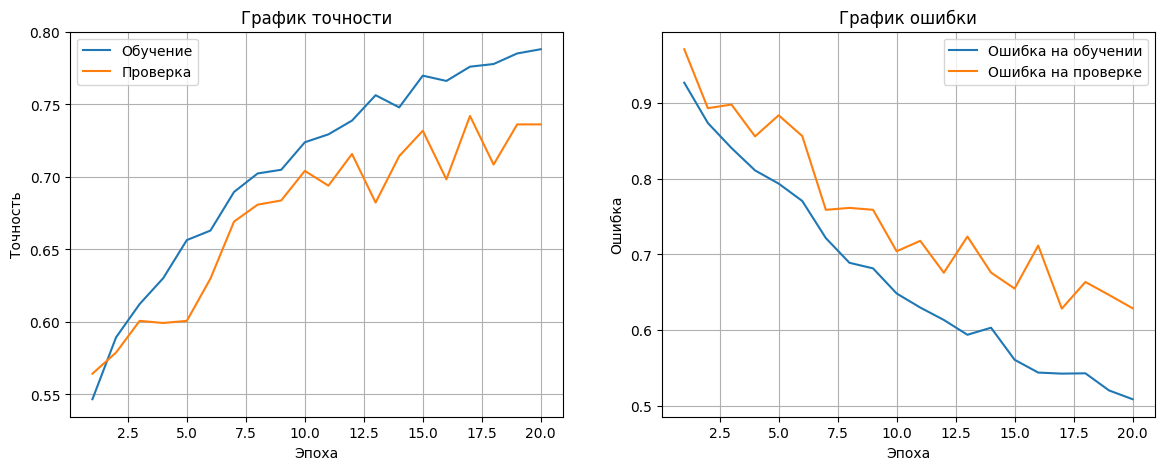

In [7]:

cars = Cars(epochs=20, batch_size=32)

cars.train_model()
cars.show_graphs()


In [8]:

class CarsMobileNet:
    def __init__(self, epochs=15, batch_size=32, img_size=224):
        self.epochs = epochs
        self.batch_size = batch_size
        self.img_size = img_size
        self.image_path = IMAGE_PATH

        self.model = None
        self.train_data = None
        self.val_data = None
        self.base_model = None
        self.history = None

        self.class_list = None
        self.class_count = None

    def load_data(self):
        # Получаем список папок с классами автомобилей
        self.class_list = sorted([
            name for name in os.listdir(self.image_path)
            if os.path.isdir(os.path.join(self.image_path, name))
        ])
        self.class_count = len(self.class_list)

        if self.class_count == 0:
            raise ValueError('Папки с классами не найдены. Проверьте IMAGE_PATH.')

        data_images = []
        data_labels = []

        for class_label, class_name in enumerate(self.class_list):
            class_path = os.path.join(self.image_path, class_name)
            class_files = sorted([
                file_name for file_name in os.listdir(class_path)
                if file_name.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))
            ])

            print(f'Размер класса {class_name}: {len(class_files)} изображений')

            for file_name in class_files:
                file_path = os.path.join(class_path, file_name)
                try:
                    with Image.open(file_path) as img:
                        img = img.convert('RGB')
                        img = img.resize((self.img_size, self.img_size))
                        data_images.append(np.array(img))
                        data_labels.append(class_label)
                except Exception as error:
                    print('Файл пропущен:', file_path, '| причина:', error)

        if len(data_labels) == 0:
            raise ValueError('Изображения не загружены. Проверьте структуру архива.')

        x_data = np.array(data_images, dtype='float32')
        y_data = np.array(data_labels, dtype='int64')

        print('Общий размер базы:', len(y_data))
        print('Форма изображений:', x_data.shape)
        print('Форма меток:', y_data.shape)
        print('Классы:', self.class_list)

        X_train, X_val, y_train, y_val = train_test_split(
            x_data,
            y_data,
            test_size=0.2,
            random_state=SEED,
            stratify=y_data
        )

        train_datagen = ImageDataGenerator(
            preprocessing_function=preprocess_input,
            rotation_range=20,
            width_shift_range=0.1,
            height_shift_range=0.1,
            zoom_range=0.2,
            horizontal_flip=True
        )

        val_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

        self.train_data = train_datagen.flow(
            X_train, y_train,
            batch_size=self.batch_size,
            shuffle=True,
            seed=SEED
        )

        self.val_data = val_datagen.flow(
            X_val, y_val,
            batch_size=self.batch_size,
            shuffle=False
        )

    def create_model(self):
        # Готовая модель MobileNetV2 без верхней классификационной части
        self.base_model = MobileNetV2(
            weights='imagenet',
            include_top=False,
            input_shape=(self.img_size, self.img_size, 3)
        )

        # На первом этапе базовая модель заморожена
        self.base_model.trainable = False

        self.model = Sequential([
            Input(shape=(self.img_size, self.img_size, 3)),
            self.base_model,
            layers.GlobalAveragePooling2D(),
            Dense(128, activation='relu'),
            Dropout(0.3),
            Dense(self.class_count, activation='softmax')
        ])

        self.model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=0.0003),
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy']
        )

    def train_model(self):
        self.load_data()
        self.create_model()

        callbacks = [
            EarlyStopping(
                monitor='val_accuracy',
                patience=5,
                restore_best_weights=True
            ),
            ReduceLROnPlateau(
                monitor='val_loss',
                factor=0.5,
                patience=2,
                min_lr=1e-6,
                verbose=1
            )
        ]

        self.history = self.model.fit(
            self.train_data,
            validation_data=self.val_data,
            epochs=self.epochs,
            callbacks=callbacks
        )

        loss, accuracy = self.model.evaluate(self.val_data, verbose=0)
        print(f'Ошибка на проверке: {loss:.4f}')
        print(f'Точность на проверке: {accuracy:.4f}')
        return loss, accuracy

    def tune(self, fine_tune_layers=30, epochs=25):
        if self.model is None or self.base_model is None:
            raise ValueError('Сначала выполните mobilenet.train_model().')

        # Размораживаем базовую модель
        self.base_model.trainable = True

        # Дообучаем только последние слои, остальные оставляем замороженными
        for layer in self.base_model.layers[:-fine_tune_layers]:
            layer.trainable = False

        # BatchNormalization на маленькой базе лучше не дообучать
        for layer in self.base_model.layers:
            if isinstance(layer, tf.keras.layers.BatchNormalization):
                layer.trainable = False

        self.model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=0.00005),
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy']
        )

        callbacks = [
            EarlyStopping(
                monitor='val_accuracy',
                patience=5,
                restore_best_weights=True
            ),
            ReduceLROnPlateau(
                monitor='val_loss',
                factor=0.5,
                patience=2,
                min_lr=1e-7,
                verbose=1
            )
        ]

        self.history = self.model.fit(
            self.train_data,
            validation_data=self.val_data,
            epochs=epochs,
            callbacks=callbacks
        )

        loss, accuracy = self.model.evaluate(self.val_data, verbose=0)
        print(f'Ошибка после дообучения: {loss:.4f}')
        print(f'Точность после дообучения: {accuracy:.4f}')
        return loss, accuracy

    def show_graphs(self):
        if self.history is None:
            raise ValueError('Сначала выполните train_model() или tune().')

        epochs = range(1, len(self.history.history['accuracy']) + 1)

        plt.figure(figsize=(14, 5))

        plt.subplot(1, 2, 1)
        plt.plot(epochs, self.history.history['accuracy'], label='Обучение')
        plt.plot(epochs, self.history.history['val_accuracy'], label='Проверка')
        plt.xlabel('Эпоха')
        plt.ylabel('Точность')
        plt.title('График точности')
        plt.legend()
        plt.grid()

        plt.subplot(1, 2, 2)
        plt.plot(epochs, self.history.history['loss'], label='Ошибка на обучении')
        plt.plot(epochs, self.history.history['val_loss'], label='Ошибка на проверке')
        plt.xlabel('Эпоха')
        plt.ylabel('Ошибка')
        plt.title('График ошибки')
        plt.legend()
        plt.grid()

        plt.show()


Размер класса Ferrari: 1088 изображений
Размер класса Mercedes: 1161 изображений
Размер класса Renault: 1178 изображений
Общий размер базы: 3427
Форма изображений: (3427, 224, 224, 3)
Форма меток: (3427,)
Классы: ['Ferrari', 'Mercedes', 'Renault']
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 203s 5s/step - accuracy: 0.6330 - loss: 0.7987 - val_accuracy: 0.7755 - val_loss: 0.5577 - learning_rate: 3.0000e-04
Epoch 2/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 178s 4s/step - accuracy: 0.7559 - loss: 0.5873 - val_accuracy: 0.8076 - val_loss: 0.5020 - learning_rate: 3.0000e-04
Epoch 3/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 188s 4s/step - accuracy: 0.7826 - loss: 0.5256 - val_accuracy: 0.8280 - val_loss: 0.4648 - learning_rate: 3.0000e-04
Epoch 4/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 194s 5s/step - accuracy: 0.7913 - loss: 0.4958 - val_accuracy: 0.8367 - val_loss: 0.4454 - learning_rate: 3.0000e-04
Epoch 5/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 187s 4s/step - accuracy: 0.8041 - loss: 0.472

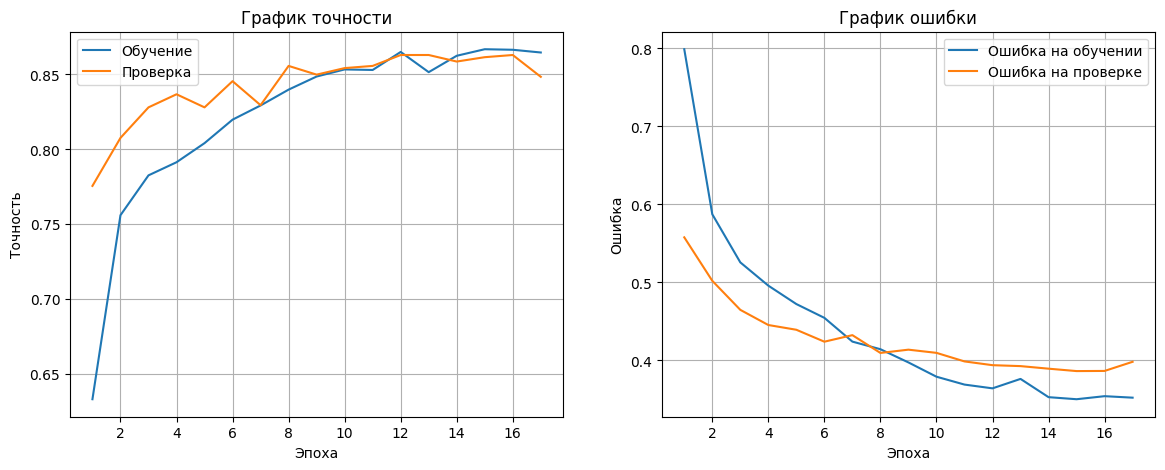

In [9]:

mobilenet = CarsMobileNet(epochs=20, batch_size=64)

mobilenet.train_model()
mobilenet.show_graphs()


In [ ]:

mobilenet.tune(fine_tune_layers=30, epochs=5)
mobilenet.show_graphs()


Epoch 1/5
43/43 ━━━━━━━━━━━━━━━━━━━━ 229s 5s/step - accuracy: 0.9376 - loss: 0.1629 - val_accuracy: 0.8834 - val_loss: 0.3726 - learning_rate: 5.0000e-05
Epoch 2/5
22/43 ━━━━━━━━━━━━━━━━━━━━ 1:18 4s/step - accuracy: 0.9443 - loss: 0.1532